# 1. Data Preparation
This [dataset](https://www.kaggle.com/datasets/rabieelkharoua/air-quality-and-health-impact-dataset) contains comprehensive information on the air quality and its impact on public health for 5,811 records. It includes variables such as air quality index (AQI), concentrations of various pollutants, weather conditions, and health impact metrics. The target variable is the health impact class, which categorizes the health impact based on the air quality and other related factors.

This dataset offers a comprehensive view of the relationship between air quality and public health, making it ideal for research, predictive modeling, and statistical analysis.

In [1]:
include("utils.jl")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
┌ Info: Running `conda install -y -c anaconda conda` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - anaconda
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - conda


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::certifi-2024.8.30~ --> anaconda/linux-64::certifi-2024.8.30-py312h06a4308_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


┌ Info: Running `conda install -y -c conda-forge 'libstdcxx-ng>=3.4,<13.0'` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - conda-forge
 - bioconda
 - defaults
 - anaconda
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - libstdcxx-ng[version='>=3.4,<13.0']


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            anaconda/linux-64::certifi-2024.8.30-~ --> conda-forge/noarch::certifi-2024.8.30-pyhd8ed1ab_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


averageAccuracies (generic function with 1 method)

In [7]:
using CSV, DataFrames

# Load the dataset from the 'dataset' folder
data = CSV.read("datasets/air_quality_health_impact_data.csv", DataFrame)

# Check the dataset
describe(data)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,RecordID,2906.0,1,2906.0,5811,0,Int64
2,AQI,248.438,0.00581738,249.128,499.859,0,Float64
3,PM10,148.655,0.0158481,147.635,299.902,0,Float64
4,PM2_5,100.224,0.0315489,100.506,199.985,0,Float64
5,NO2,102.293,0.00962478,102.988,199.98,0,Float64
6,SO2,49.4568,0.0110232,49.5302,99.9696,0,Float64
7,O3,149.312,0.001661,149.56,299.937,0,Float64
8,Temperature,14.9755,-9.991,14.9424,39.9634,0,Float64
9,Humidity,54.7769,10.0015,54.5439,99.9975,0,Float64


In [8]:
# Count elements in each class
counts = combine(groupby(data, :HealthImpactClass), nrow => :Count)

println("Elements per class:")
println(counts)

Elements per class:
5×2 DataFrame
 Row │ HealthImpactClass  Count 
     │ Float64            Int64 
─────┼──────────────────────────
   1 │               0.0   4808
   2 │               1.0    579
   3 │               2.0    273
   4 │               3.0     95
   5 │               4.0     56


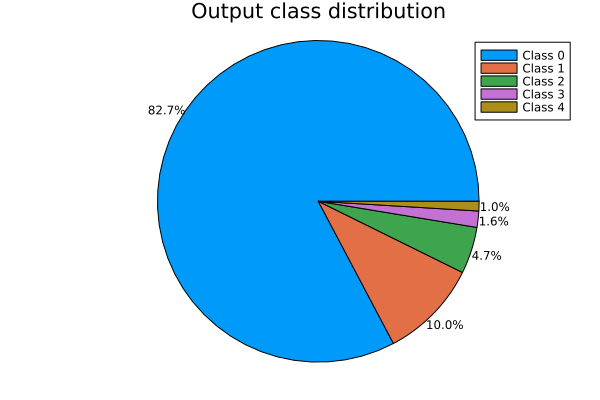

In [10]:
using Plots, Printf

cnt = counts.Count
labels = ["Class $i" for i in 0:4]
tot = sum(cnt)
datapct = [@sprintf("%.1f%%", x/tot*100) for x in cnt]

θ = (cumsum(cnt) - cnt/2) .* 360/sum(cnt)
scθ = sincosd.(θ)

p = pie(labels, cnt, title="Output class distribution")
for (s, sci) in zip(datapct, scθ)
    annotate!(1.1*sci[2], 1.1*sci[1], text(s, 8, :black))
end
p

In [11]:
input_data = Matrix(data[!, 1:13]);
output_data = Int.(data[!, 15]);

@assert input_data isa Matrix
@assert output_data isa Vector{Int64}

To split the test from train we use the holdOut function with a fraction of 0.2. This means that 20% of the train data will be used for testing and the remaining 80% will be used for training.

In [12]:
# Split in train and test
(tr_idx, test_idx) = holdOutStratified(output_data, 0.2)

train_input = input_data[tr_idx,:]
train_output = output_data[tr_idx]
test_input = input_data[test_idx,:]
test_output = output_data[test_idx]

train_output = collect(train_output)
test_output = collect(test_output)

println("Train Input Size: ", size(train_input))
println("Train Output Size: ", size(train_output), " Categories:", sort(unique(train_output)))
println("Test Input Size: ", size(test_input))
println("Test Output Size: ", size(test_output), " Categories:", sort(unique(test_output)))

Train Input Size: (4648, 13)
Train Output Size: (4648,) Categories:[0, 1, 2, 3, 4]
Test Input Size: (1163, 13)
Test Output Size: (1163,) Categories:[0, 1, 2, 3, 4]


In [14]:
columna = train_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 3846, 4 => 45, 2 => 218, 3 => 76, 1 => 463)


In [15]:
columna = test_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 962, 4 => 11, 2 => 55, 3 => 19, 1 => 116)


We will store the results in a DataFrame for easy ploting

In [13]:
metric_names = [:approach, :accuracy, :error_rate, :recall, :specificity, :ppv, :npv, :f_score]
metric_types = [String[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[]]
metrics = DataFrame(metric_types, metric_names)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


# 2. Definition of Models and Hyperparameters

In [16]:
## These are the modelsHyperParameters to be used in the models training

modelsHyperParameters = [
    # ANN configurations
    Dict("estimator" => :ANN, "topology" => (64,), "maxEpochs" => 200, "learningRate" => 0.01),
    Dict("estimator" => :ANN, "topology" => (128,), "maxEpochs" => 500, "learningRate" => 0.005),
    # Dict("estimator" => :ANN, "topology" => (64, 32), "maxEpochs" => 400, "learningRate" => 0.001),
    # Dict("estimator" => :ANN, "topology" => (128, 64), "maxEpochs" => 200, "learningRate" => 0.01),
    # Dict("estimator" => :ANN, "topology" => (256,), "maxEpochs" => 300, "learningRate" => 0.05),
    # Dict("estimator" => :ANN, "topology" => (128, 64, 32), "maxEpochs" => 200, "learningRate" => 0.01),
    # Dict("estimator" => :ANN, "topology" => (64, 64), "maxEpochs" => 250, "learningRate" => 0.005),
    # Dict("estimator" => :ANN, "topology" => (256, 128), "maxEpochs" => 200, "learningRate" => 0.001),

    # SVM configurations
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.5, "degree"=>2),
    Dict("estimator" => :SVM, "kernel" => "linear", "C" => 1.0, "degree"=>4),
    # Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 0.01 , "degree" => 2),
    # Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 1.0, "degree" => 3),
    # Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.01, "degree" => 3),
    # Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 5, "degree" => 3),
    # Dict("estimator" => :SVM, "kernel" => "linear", "C"=> 0.5, "degree" => 3),
    # Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 10.0, "degree" => 5),

    # Decision Tree configurations
    Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42),
    Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42),
    # Dict("estimator" => :DecisionTree, "max_depth" => 7, "random_state" => 42),
    # Dict("estimator" => :DecisionTree, "max_depth" => 10, "random_state" => 42),
    # Dict("estimator" => :DecisionTree, "max_depth" => 15, "random_state" => 42),
    # Dict("estimator" => :DecisionTree, "max_depth" => 20, "random_state" => 42),

    # kNN configurations
    Dict("estimator" => :KNN, "k" => 3),
    Dict("estimator" => :KNN, "k" => 5),
    # Dict("estimator" => :KNN, "k" => 7),
    # Dict("estimator" => :KNN, "k" => 9),
    # Dict("estimator" => :KNN, "k" => 11),
    # Dict("estimator" => :KNN, "k" => 15)
]

# println(modelsHyperParameters)

8-element Vector{Dict{String, Any}}:
 Dict("maxEpochs" => 200, "learningRate" => 0.01, "estimator" => :ANN, "topology" => (64,))
 Dict("maxEpochs" => 500, "learningRate" => 0.005, "estimator" => :ANN, "topology" => (128,))
 Dict("estimator" => :SVM, "C" => 0.5, "kernel" => "rbf", "degree" => 2)
 Dict("estimator" => :SVM, "C" => 1.0, "kernel" => "linear", "degree" => 4)
 Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42)
 Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42)
 Dict("estimator" => :KNN, "k" => 3)
 Dict("estimator" => :KNN, "k" => 5)

----
----

# 3. First approach: Using Min-Max Normalization.

In this approach we will use the Min-Max Normalization technique to normalize the data. And then, realize all the models training to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [17]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.8559132380788431 0.7074752476135373 … 0.21428571428571427 0.08333333333333333; 0.8338784644517129 0.3923214860786344 … 0.6428571428571429 0.25; … ; 0.9163367188844895 0.054970831390816675 … 0.35714285714285715 0.25; 0.38233775176450335 0.09655121777790915 … 0.5 0.08333333333333333], [0.29970735066276466 0.7695194679593804 … 0.5714285714285714 0.3333333333333333; 0.8710621449474952 0.9229048033001486 … 0.35714285714285715 0.0; … ; 0.025477707006369428 0.2787167614699476 … 0.42857142857142855 0.4166666666666667; 0.5629196075055948 0.009970072720308478 … 0.21428571428571427 0.3333333333333333])

In this approach we wont use crossValidation, so we will train the models on the whole dataset and then evaluate them on the test set.

Pre-normalization data characteristics:

In [18]:
describe(DataFrame(train_input, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,2916.34,2.0,2926.5,5811.0,0,Float64
2,AQI,247.922,0.00581738,246.311,499.859,0,Float64
3,PM10,148.548,0.0158481,146.541,299.902,0,Float64
4,PM2_5,101.023,0.0504909,101.912,199.985,0,Float64
5,NO2,102.019,0.00962478,102.191,199.974,0,Float64
6,SO2,49.5539,0.0110232,49.6626,99.9696,0,Float64
7,O3,150.204,0.001661,151.216,299.937,0,Float64
8,Temperature,15.0139,-9.96548,14.9992,39.9634,0,Float64
9,Humidity,54.6833,10.0084,54.355,99.9902,0,Float64


Post-normalization data with min-max:

In [19]:
describe(DataFrame(train_input_minmax, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.501694,0.0,0.503443,1.0,0,Float64
2,AQI,0.495978,0.0,0.492755,1.0,0,Float64
3,PM10,0.495297,0.0,0.488603,1.0,0,Float64
4,PM2_5,0.505028,0.0,0.509477,1.0,0,Float64
5,NO2,0.510137,0.0,0.510996,1.0,0,Float64
6,SO2,0.495634,0.0,0.496722,1.0,0,Float64
7,O3,0.500783,0.0,0.504158,1.0,0,Float64
8,Temperature,0.500298,0.0,0.500005,1.0,0,Float64
9,Humidity,0.496488,0.0,0.49284,1.0,0,Float64


In [20]:
accuracies = []
models = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = deepcopy(genModel(modelHyperParameters))
    fit!(model, train_input_minmax, train_output)
    acc = score(model, test_input_minmax, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Once we have the accuracies, we will take the best of each model to create the ensemble, in this case we will create a stack, and then train the stack.

In [21]:
println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_minmax, train_output)

Any[(1, :ANN, 0.937231298366294), (2, :ANN, 0.9363714531384351), (3, :SVM, 0.8968185726569218), (4, :SVM, 0.9088564058469476), (5, :DecisionTree, 0.8460877042132416), (6, :DecisionTree, 0.8667239896818573), (7, :KNN, 0.8400687876182287), (8, :KNN, 0.8469475494411006)]


/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

PyObject StackingClassifier(estimators=[('m8_KNN', KNeighborsClassifier()),
                               ('m4_SVM', SVC(degree=4, kernel='linear')),
                               ('m1_ANN',
                                MLPClassifier(hidden_layer_sizes=(64,),
                                              learning_rate_init=0.01)),
                               ('m6_DecisionTree',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

Now we get the metrics of the stack ensemble.

In [39]:
outputs = stacking_classifier.predict(test_input_minmax)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_minmax = [
    "MinMax",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_minmax)


Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.94411,0.0558899,2.62903,4.77378,4.62673,4.91108,2.62689


And print the metrics for this First Approach:

In [40]:
# Display results
println("METRICS 1st APPROACH (Min-Max Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 1st APPROACH (Min-Max Normalization):
---------------------
Accuracy: 0.944110060189166
Error Rate: 0.05588993981083401
Sensitivity (Recall): 2.6290294514432446
Specificity: 4.773780840298008
Precision: 4.626733772746813
Negative Predictive Value: 4.91107560697221
F-Score: 2.6268891368974034
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       956         6         0         0         0
   Class 1        14        99         3         0         0
   Class 2        11         1        43         0         0
   Class 3         8         2         1         0         0
   Class 4         8         2         9         0         0


----
----

# 4. Second Approach: Using Standard normalization

In this approach we will use the Zero-Mean Normalization technique to normalize the data. And then, train the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [41]:
train_input_zm, test_input_zm = normalizeData(train_input, test_input, :MinMax)

([0.8559132380788431 0.7074752476135373 … 0.21428571428571427 0.08333333333333333; 0.8338784644517129 0.3923214860786344 … 0.6428571428571429 0.25; … ; 0.9163367188844895 0.054970831390816675 … 0.35714285714285715 0.25; 0.38233775176450335 0.09655121777790915 … 0.5 0.08333333333333333], [0.29970735066276466 0.7695194679593804 … 0.5714285714285714 0.3333333333333333; 0.8710621449474952 0.9229048033001486 … 0.35714285714285715 0.0; … ; 0.025477707006369428 0.2787167614699476 … 0.42857142857142855 0.4166666666666667; 0.5629196075055948 0.009970072720308478 … 0.21428571428571427 0.3333333333333333])

Post-normalization data with zero-mean:

In [42]:
describe(DataFrame(train_input_zm, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.501694,0.0,0.503443,1.0,0,Float64
2,AQI,0.495978,0.0,0.492755,1.0,0,Float64
3,PM10,0.495297,0.0,0.488603,1.0,0,Float64
4,PM2_5,0.505028,0.0,0.509477,1.0,0,Float64
5,NO2,0.510137,0.0,0.510996,1.0,0,Float64
6,SO2,0.495634,0.0,0.496722,1.0,0,Float64
7,O3,0.500783,0.0,0.504158,1.0,0,Float64
8,Temperature,0.500298,0.0,0.500005,1.0,0,Float64
9,Humidity,0.496488,0.0,0.49284,1.0,0,Float64


In [43]:
accuracies = []
models = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_zm, train_output)
    acc = score(model, test_input_zm, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [44]:
println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_zm, train_output)

Any[(1, :ANN, 0.944110060189166), (2, :ANN, 0.937231298366294), (3, :SVM, 0.8968185726569218), (4, :SVM, 0.9088564058469476), (5, :DecisionTree, 0.8460877042132416), (6, :DecisionTree, 0.8667239896818573), (7, :KNN, 0.8400687876182287), (8, :KNN, 0.8469475494411006)]


/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


PyObject StackingClassifier(estimators=[('m8_KNN', KNeighborsClassifier()),
                               ('m4_SVM', SVC(degree=4, kernel='linear')),
                               ('m1_ANN',
                                MLPClassifier(hidden_layer_sizes=(64,),
                                              learning_rate_init=0.01)),
                               ('m6_DecisionTree',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

In [45]:
outputs = stacking_classifier.predict(test_input_zm)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_zm = [
    "ZeroMean",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_zm)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.94411,0.0558899,2.62903,4.77378,4.62673,4.91108,2.62689
2,ZeroMean,0.94583,0.0541702,2.61595,4.75538,4.70501,4.93271,2.65718


In [46]:
# Display results
println("METRICS 2nd APPROACH (Zero-Mean Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 2nd APPROACH (Zero-Mean Normalization):
---------------------
Accuracy: 0.945829750644884
Error Rate: 0.05417024935511605
Sensitivity (Recall): 2.6159460762909035
Specificity: 4.755380656223604
Precision: 4.70500695460934
Negative Predictive Value: 4.932706297454736
F-Score: 2.6571761281532127
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       960         2         0         0         0
   Class 1        19        97         0         0         0
   Class 2        11         1        43         0         0
   Class 3         8         3         0         0         0
   Class 4         8         2         9         0         0


----
----

# 5. Third Approach: Using Crossvalidation

In this approach we will use the Crossvalidation technique to train the models, and using the normalization of the data that gave us the best results in the previous steps.

In [48]:
kFoldIndices = crossvalidation(size(train_output, 1), 5)

metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (train_input_minmax, train_output), 
                                    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.54305, 0.0957337)
  "positive_predictive_value" => (4.59236, 0.0398197)
  "specificity"               => (4.74537, 0.0263174)
  "negative_predictive_value" => (4.90361, 0.0262416)
  "f_score"                   => (2.56409, 0.0645143)
  "accuracy"                  => (0.938469, 0.00753034)
  "error_rate"                => (0.0615306, 0.00753034)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.930293)…

In [56]:
metrics_cv = [
    "CrossVal",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_cv)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.94411,0.0558899,2.62903,4.77378,4.62673,4.91108,2.62689
2,ZeroMean,0.94583,0.0541702,2.61595,4.75538,4.70501,4.93271,2.65718
3,CrossVal,0.938469,0.0615306,2.54305,4.74537,4.59236,4.90361,2.56409


In [57]:
# Display results
println("METRICS 3rd APPROACH (Cross-Validation):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 3rd APPROACH (Cross-Validation):
---------------------
Accuracy: 0.9384693912983089
Error Rate: 0.061530608701691025
Sensitivity (Recall): 2.54305274018805
Specificity: 4.745370757897062
Precision: 4.592359660762844
Negative Predictive Value: 4.903608009628293
F-Score: 2.5640865305209197
----------------------



In [62]:
metrics_given["models_accuracies"]

8-element Vector{Tuple{Int64, Any, Float64}}:
 (1, :ANN, 0.9302934129657279)
 (2, :ANN, 0.9285727513686817)
 (3, :SVM, 0.8844670532541639)
 (4, :SVM, 0.9066270819588643)
 (5, :DecisionTree, 0.8425153651168443)
 (6, :DecisionTree, 0.8672569649409123)
 (7, :KNN, 0.8423026262485965)
 (8, :KNN, 0.8438061506765282)

### At this point we have the accuracies of the models and the metrics of the stack. We can compare directly the results with the Approach 1 (MinMax).

____
____

# Ploting

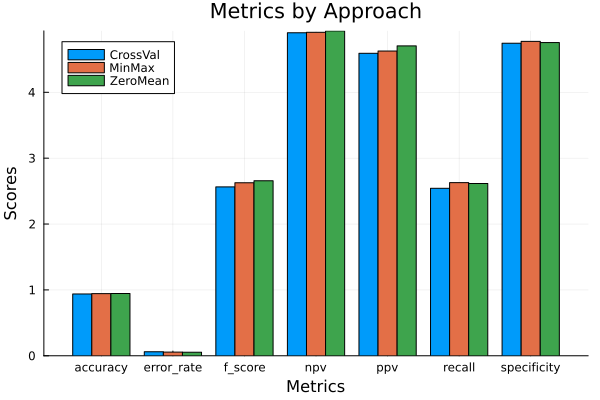

In [64]:
using StatsPlots

df = copy(metrics)

ctg = repeat(["MinMax", "ZeroMean", "CrossVal"], inner=7)
nam = repeat(names(df)[2:8], outer=3)
mm = collect(df[1,2:8])
zm = collect(df[2,2:8])
cv = collect(df[3,2:8])

groupedbar(nam, [mm zm cv], group = ctg, xlabel = "Metrics", ylabel = "Scores",
           title = "Metrics by Approach")

In [168]:
results = metrics_given["models_accuracies"]

8-element Vector{Tuple{Int64, Any, Float64}}:
 (1, :ANN, 0.9302934129657279)
 (2, :ANN, 0.9285727513686817)
 (3, :SVM, 0.8844670532541639)
 (4, :SVM, 0.9066270819588643)
 (5, :DecisionTree, 0.8425153651168443)
 (6, :DecisionTree, 0.8672569649409123)
 (7, :KNN, 0.8423026262485965)
 (8, :KNN, 0.8438061506765282)

In [179]:
auc_value

1.0

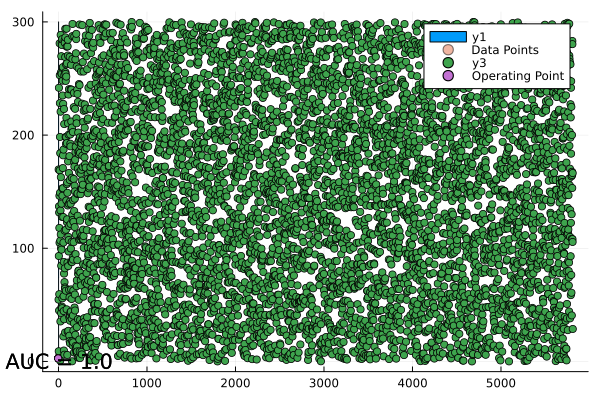

In [181]:
using Plots
using ROCAnalysis

sensitivity = metrics.recall[1]
specificity = metrics.specificity[1]
false_positive_rate = 1 - specificity

r = roc([false_positive_rate], [sensitivity])

# plot(r, xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
# plot!([0, 1], [0, 1], label="Random Classifier", linestyle=:dash)

auc_value = ROCAnalysis.auc(r)
annotate!(0.5, 0.2, text("AUC = $(round(auc_value, digits=3))", :black))

# scatter!([false_positive_rate], [sensitivity], label="Operating Point")